# Employee Attrition Analytics

## Module 12: Business Analytics

### Objective

Analyze employee attrition from a business perspective and prepare data for an interactive HR analytics dashboard.

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load Cleaned Employee Dataset

In [ ]:
df = pd.read_csv("../data/processed/employee_hr_analytics_clean.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1000, 22)


,Employee_ID,Age,Gender,Department,Job_Role,Experience,Education,Salary,Performance_Score,Job_Satisfaction,...,Remote_Work,Training_Hours,Projects,Promotion_Last_5Yrs,Joining_Date,Attrition,City,Employment_Type,Manager_Rating,Sick_Leaves
0,1,40.0,Male,Sales,Sales Manager,3,Master,94113.0,5,6.0,...,No,70,5,No,2011-12-21,No,Rawalpindi,Contract,5,6
1,2,39.0,Female,Sales,Sales Manager,2,Master,54224.0,4,9.0,...,No,33,3,Yes,2015-09-20,No,Islamabad,Full-Time,4,4
2,3,49.0,Male,Finance,Financial Analyst,25,Master,166749.0,2,6.0,...,Yes,75,12,No,2014-12-10,No,Islamabad,Full-Time,8,2
3,4,54.0,Female,Marketing,Marketing Specialist,26,Bachelor,196590.0,5,4.0,...,Yes,64,12,No,2022-08-23,Yes,Rawalpindi,Contract,4,5
4,5,41.0,Female,IT,Data Analyst,18,PhD,231764.0,3,8.0,...,Yes,15,12,No,2021-09-29,No,Rawalpindi,Contract,10,8


## Inspect Dataset

In [31]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

Columns:
['Employee_ID', 'Age', 'Gender', 'Department', 'Job_Role', 'Experience', 'Education', 'Salary', 'Performance_Score', 'Job_Satisfaction', 'Overtime', 'Work_Hours', 'Remote_Work', 'Training_Hours', 'Projects', 'Promotion_Last_5Yrs', 'Joining_Date', 'Attrition', 'City', 'Employment_Type', 'Manager_Rating', 'Sick_Leaves']

Dataset shape:
(1000, 22)

Missing values:
0


## Overall Attrition Rate

In [ ]:
total_employees = len(df)

employees_left = df["Attrition"].eq("Yes").sum()

attrition_rate = (employees_left / total_employees) * 100

print("Total Employees:", total_employees)
print("Employees Left:", employees_left)
print("Attrition Rate:", round(attrition_rate, 2), "%")

Total Employees: 1000
Employees Left: 118
Attrition Rate: 11.8 %


## Attrition Distribution

In [33]:
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

Attrition
No     882
Yes    118
Name: count, dtype: int64


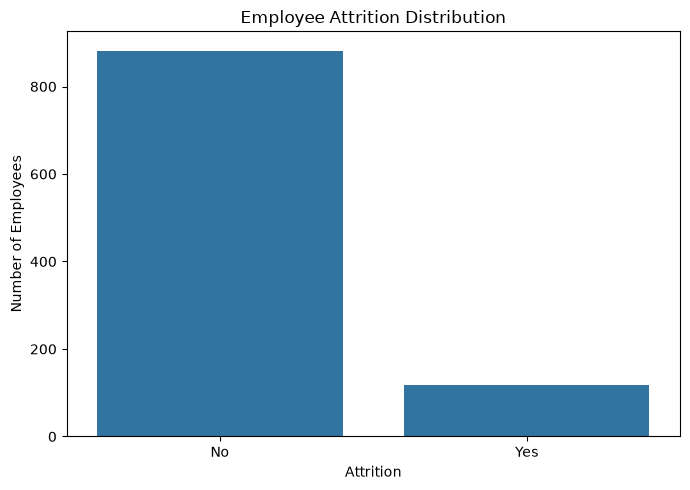

In [34]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")

plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

## Attrition by Department

In [ ]:
department_attrition = (
    df.groupby("Department")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

department_attrition["Attrition_Rate"] = (
    department_attrition["Employees_Left"] / department_attrition["Total_Employees"]
) * 100

department_attrition = department_attrition.sort_values(
    "Attrition_Rate", ascending=False
)

department_attrition

,Department,Total_Employees,Employees_Left,Attrition_Rate
3,Marketing,196,29,14.795918
2,IT,182,23,12.637363
4,Sales,199,25,12.562814
1,HR,229,24,10.480349
0,Finance,194,17,8.762887


## Department Attrition Rate

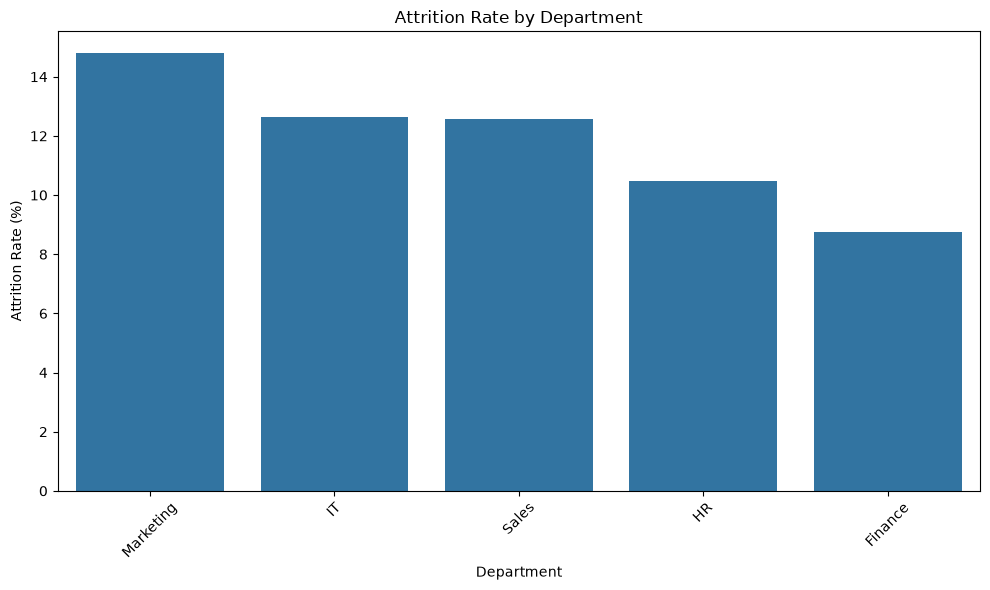

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(data=department_attrition, x="Department", y="Attrition_Rate")

plt.title("Attrition Rate by Department")

plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Salary Analysis

In [38]:
salary_attrition = df.groupby("Attrition")["Salary"].agg(
    ["count", "mean", "median", "min", "max"]
)

salary_attrition

,count,mean,median,min,max
Attrition,,,,,
No,882,128396.048469,119197.50,40039.0,352095.375
Yes,118,124779.038136,118791.75,41732.0,236298.000


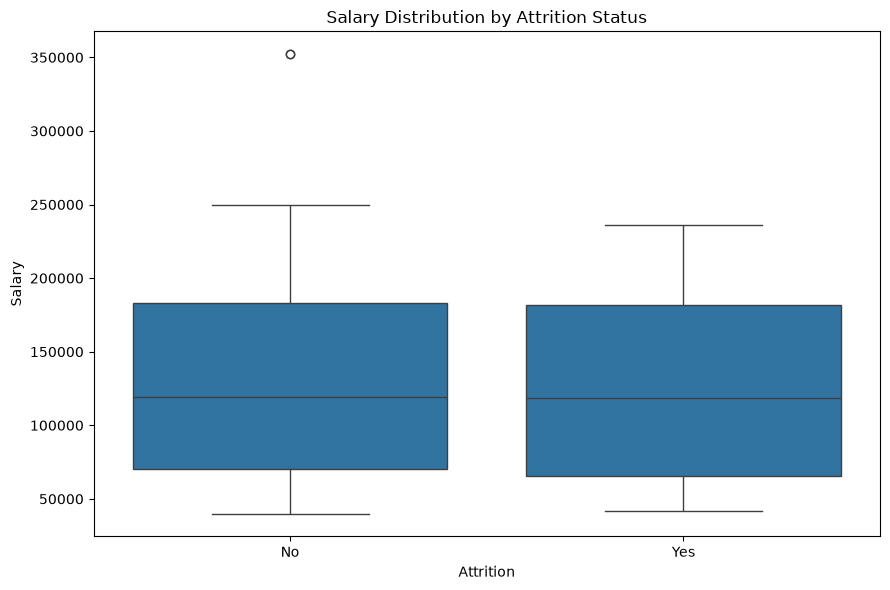

In [39]:
plt.figure(figsize=(9, 6))

sns.boxplot(data=df, x="Attrition", y="Salary")

plt.title("Salary Distribution by Attrition Status")

plt.xlabel("Attrition")
plt.ylabel("Salary")

plt.tight_layout()
plt.show()

## Experience Analysis

In [ ]:
experience_attrition = df.groupby("Attrition")["Experience"].agg(
    ["count", "mean", "median", "min", "max"]
)

experience_attrition

,count,mean,median,min,max
Attrition,,,,,
No,882,9.778912,7.0,0,38
Yes,118,9.872881,6.0,0,36


## Experience Distribution by Attrition

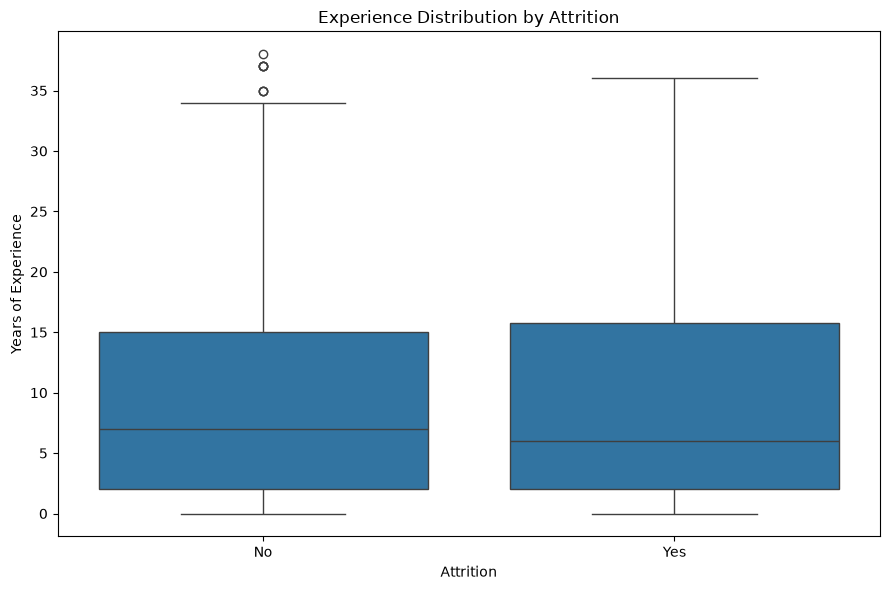

In [42]:
plt.figure(figsize=(9, 6))

sns.boxplot(data=df, x="Attrition", y="Experience")

plt.title("Experience Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years of Experience")

plt.tight_layout()
plt.show()

## Overtime Analysis

In [43]:
overtime_attrition = (
    df.groupby("Overtime")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

overtime_attrition["Attrition_Rate"] = (
    overtime_attrition["Employees_Left"] / overtime_attrition["Total_Employees"]
) * 100

overtime_attrition

,Overtime,Total_Employees,Employees_Left,Attrition_Rate
0,No,510,0,0.000000
1,Yes,490,118,24.081633


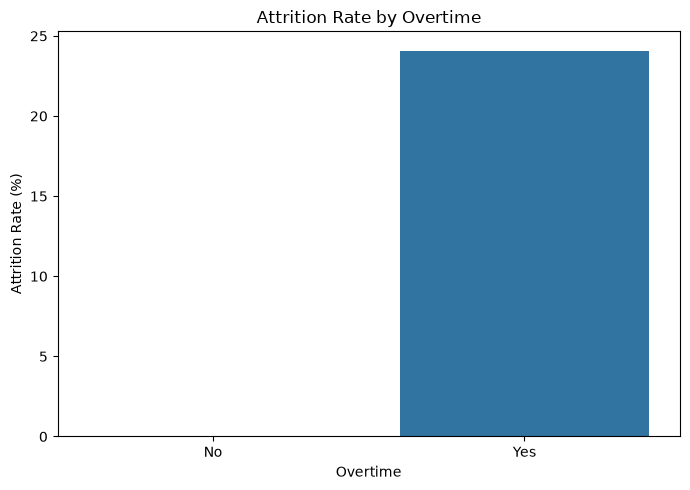

In [44]:
plt.figure(figsize=(7, 5))

sns.barplot(data=overtime_attrition, x="Overtime", y="Attrition_Rate")

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

## Promotion Analysis

In [45]:
promotion_attrition = (
    df.groupby("Promotion_Last_5Yrs")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

promotion_attrition["Attrition_Rate"] = (
    promotion_attrition["Employees_Left"] / promotion_attrition["Total_Employees"]
) * 100

promotion_attrition

,Promotion_Last_5Yrs,Total_Employees,Employees_Left,Attrition_Rate
0,No,794,92,11.586902
1,Yes,206,26,12.621359


## Education Analysis

In [46]:
education_attrition = (
    df.groupby("Education")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

education_attrition["Attrition_Rate"] = (
    education_attrition["Employees_Left"] / education_attrition["Total_Employees"]
) * 100

education_attrition = education_attrition.sort_values("Attrition_Rate", ascending=False)

education_attrition

,Education,Total_Employees,Employees_Left,Attrition_Rate
0,Bachelor,346,49,14.161850
1,Master,325,37,11.384615
2,PhD,329,32,9.726444


## Age Analysis

In [47]:
age_attrition = df.groupby("Attrition")["Age"].agg(
    ["count", "mean", "median", "min", "max"]
)

age_attrition

,count,mean,median,min,max
Attrition,,,,,
No,882,40.376417,40.0,22.0,60.0
Yes,118,39.983051,39.0,22.0,60.0


## Project Workload Analysis

In [ ]:
project_attrition = df.groupby("Attrition")["Projects"].agg(
    ["count", "mean", "median", "min", "max"]
)

project_attrition

,count,mean,median,min,max
Attrition,,,,,
No,882,7.198413,7.0,1,15
Yes,118,6.830508,6.5,1,15


## Attrition by City

In [49]:
city_attrition = (
    df.groupby("City")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

city_attrition["Attrition_Rate"] = (
    city_attrition["Employees_Left"] / city_attrition["Total_Employees"]
) * 100

city_attrition = city_attrition.sort_values("Attrition_Rate", ascending=False)

city_attrition

,City,Total_Employees,Employees_Left,Attrition_Rate
5,Rawalpindi,171,28,16.374269
0,Faisalabad,159,22,13.836478
4,Peshawar,187,22,11.764706
1,Islamabad,166,19,11.445783
3,Lahore,153,14,9.150327
2,Karachi,164,13,7.926829


## Employment Type Analysis

In [50]:
employment_attrition = (
    df.groupby("Employment_Type")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum()),
    )
    .reset_index()
)

employment_attrition["Attrition_Rate"] = (
    employment_attrition["Employees_Left"] / employment_attrition["Total_Employees"]
) * 100

employment_attrition

,Employment_Type,Total_Employees,Employees_Left,Attrition_Rate
0,Contract,472,57,12.076271
1,Full-Time,528,61,11.553030


## Job Satisfaction and Attrition

In [51]:
satisfaction_attrition = df.groupby("Attrition")["Job_Satisfaction"].agg(
    ["count", "mean", "median", "min", "max"]
)

satisfaction_attrition

,count,mean,median,min,max
Attrition,,,,,
No,882,7.168934,7.0,3.0,10.0
Yes,118,3.576271,3.0,3.0,7.0


## Performance and Attrition

In [52]:
performance_attrition = df.groupby("Attrition")["Performance_Score"].agg(
    ["count", "mean", "median", "min", "max"]
)

performance_attrition

,count,mean,median,min,max
Attrition,,,,,
No,882,2.995465,3.0,1,5
Yes,118,3.033898,3.0,1,5


## Work Hours and Attrition

In [53]:
work_hours_attrition = df.groupby("Attrition")["Work_Hours"].agg(
    ["count", "mean", "median", "min", "max"]
)

work_hours_attrition

,count,mean,median,min,max
Attrition,,,,,
No,882,44.829932,45.0,35,55
Yes,118,44.567797,43.0,35,55


## Training and Attrition

In [ ]:
training_attrition = df.groupby("Attrition")["Training_Hours"].agg(
    ["count", "mean", "median", "min", "max"]
)

training_attrition

,count,mean,median,min,max
Attrition,,,,,
No,882,41.992063,41.0,5,80
Yes,118,42.144068,45.5,5,80


## Manager Rating and Attrition

In [ ]:
manager_rating_attrition = df.groupby("Attrition")["Manager_Rating"].agg(
    ["count", "mean", "median", "min", "max"]
)

manager_rating_attrition

,count,mean,median,min,max
Attrition,,,,,
No,882,7.027211,7.0,4,10
Yes,118,7.025424,7.0,4,10


## Sick Leaves and Attrition

In [56]:
sick_leave_attrition = df.groupby("Attrition")["Sick_Leaves"].agg(
    ["count", "mean", "median", "min", "max"]
)

sick_leave_attrition

,count,mean,median,min,max
Attrition,,,,,
No,882,7.484127,8.0,0,15
Yes,118,7.177966,6.5,0,15


## Executive HR KPIs

In [57]:
kpi_table = pd.DataFrame(
    {
        "KPI": [
            "Total Employees",
            "Employees Left",
            "Attrition Rate",
            "Average Salary",
            "Average Experience",
            "Average Job Satisfaction",
            "Average Work Hours",
            "Average Training Hours",
            "Average Projects",
        ],
        "Value": [
            total_employees,
            employees_left,
            round(attrition_rate, 2),
            round(df["Salary"].mean(), 2),
            round(df["Experience"].mean(), 2),
            round(df["Job_Satisfaction"].mean(), 2),
            round(df["Work_Hours"].mean(), 2),
            round(df["Training_Hours"].mean(), 2),
            round(df["Projects"].mean(), 2),
        ],
    }
)

kpi_table

,KPI,Value
0,Total Employees,1000.00
1,Employees Left,118.00
2,Attrition Rate,11.80
3,Average Salary,127969.24
4,Average Experience,9.79
5,Average Job Satisfaction,6.74
6,Average Work Hours,44.80
7,Average Training Hours,42.01
8,Average Projects,7.16


## Prepare Dashboard Dataset

In [58]:
dashboard_df = df.copy()

dashboard_df["Attrition_Flag"] = dashboard_df["Attrition"].map({"Yes": 1, "No": 0})

dashboard_df["Salary_Thousands"] = dashboard_df["Salary"] / 1000

dashboard_df.head()

,Employee_ID,Age,Gender,Department,Job_Role,Experience,Education,Salary,Performance_Score,Job_Satisfaction,...,Projects,Promotion_Last_5Yrs,Joining_Date,Attrition,City,Employment_Type,Manager_Rating,Sick_Leaves,Attrition_Flag,Salary_Thousands
0,1,40.0,Male,Sales,Sales Manager,3,Master,94113.0,5,6.0,...,5,No,2011-12-21,No,Rawalpindi,Contract,5,6,0,94.113
1,2,39.0,Female,Sales,Sales Manager,2,Master,54224.0,4,9.0,...,3,Yes,2015-09-20,No,Islamabad,Full-Time,4,4,0,54.224
2,3,49.0,Male,Finance,Financial Analyst,25,Master,166749.0,2,6.0,...,12,No,2014-12-10,No,Islamabad,Full-Time,8,2,0,166.749
3,4,54.0,Female,Marketing,Marketing Specialist,26,Bachelor,196590.0,5,4.0,...,12,No,2022-08-23,Yes,Rawalpindi,Contract,4,5,1,196.590
4,5,41.0,Female,IT,Data Analyst,18,PhD,231764.0,3,8.0,...,12,No,2021-09-29,No,Rawalpindi,Contract,10,8,0,231.764


## Save Dashboard Dataset

In [ ]:
dashboard_df.to_csv("../data/processed/employee_attrition_dashboard.csv", index=False)

print("Dashboard dataset saved successfully.")

Dashboard dataset saved successfully.


## Save KPI Dataset

In [60]:
kpi_table.to_csv("../data/processed/hr_dashboard_kpis.csv", index=False)

print("KPI dataset saved successfully.")

KPI dataset saved successfully.


## Save Business Analysis Tables

In [61]:
department_attrition.to_csv(
    "../data/processed/department_attrition_analysis.csv", index=False
)

overtime_attrition.to_csv(
    "../data/processed/overtime_attrition_analysis.csv", index=False
)

promotion_attrition.to_csv(
    "../data/processed/promotion_attrition_analysis.csv", index=False
)

education_attrition.to_csv(
    "../data/processed/education_attrition_analysis.csv", index=False
)

city_attrition.to_csv("../data/processed/city_attrition_analysis.csv", index=False)

employment_attrition.to_csv(
    "../data/processed/employment_type_attrition_analysis.csv", index=False
)

print("Business analysis files saved successfully.")

Business analysis files saved successfully.
